# Industrial Pump Failure Prediction

## 1) Importing Essential Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib   # to save the trained model for the Streamlit dashboard

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## 2) Data Collection

In [2]:
df = pd.read_csv(r"C:\Users\91932\downloads\sensor.csv")
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (220320, 55)


,Unnamed: 0,timestamp,sensor_00,sensor_01,sensor_02,sensor_03,sensor_04,sensor_05,sensor_06,sensor_07,...,sensor_43,sensor_44,sensor_45,sensor_46,sensor_47,sensor_48,sensor_49,sensor_50,sensor_51,machine_status
0,0,2018-04-01 00:00:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
1,1,2018-04-01 00:01:00,2.465394,47.09201,53.2118,46.310760,634.3750,76.45975,13.41146,16.13136,...,41.92708,39.641200,65.68287,50.92593,38.194440,157.9861,67.70834,243.0556,201.3889,NORMAL
2,2,2018-04-01 00:02:00,2.444734,47.35243,53.2118,46.397570,638.8889,73.54598,13.32465,16.03733,...,41.66666,39.351852,65.39352,51.21528,38.194443,155.9606,67.12963,241.3194,203.7037,NORMAL
3,3,2018-04-01 00:03:00,2.460474,47.09201,53.1684,46.397568,628.1250,76.98898,13.31742,16.24711,...,40.88541,39.062500,64.81481,51.21528,38.194440,155.9606,66.84028,240.4514,203.1250,NORMAL
4,4,2018-04-01 00:04:00,2.445718,47.13541,53.2118,46.397568,636.4583,76.58897,13.35359,16.21094,...,41.40625,38.773150,65.10416,51.79398,38.773150,158.2755,66.55093,242.1875,201.3889,NORMAL


In [3]:
import os
print(os.getcwd())

C:\Users\91932


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220320 entries, 0 to 220319
Data columns (total 55 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Unnamed: 0      220320 non-null  int64  
 1   timestamp       220320 non-null  object 
 2   sensor_00       210112 non-null  float64
 3   sensor_01       219951 non-null  float64
 4   sensor_02       220301 non-null  float64
 5   sensor_03       220301 non-null  float64
 6   sensor_04       220301 non-null  float64
 7   sensor_05       220301 non-null  float64
 8   sensor_06       215522 non-null  float64
 9   sensor_07       214869 non-null  float64
 10  sensor_08       215213 non-null  float64
 11  sensor_09       215725 non-null  float64
 12  sensor_10       220301 non-null  float64
 13  sensor_11       220301 non-null  float64
 14  sensor_12       220301 non-null  float64
 15  sensor_13       220301 non-null  float64
 16  sensor_14       220299 non-null  float64
 17  sensor_15 

In [5]:
# quick look at how the target classes are distributed
df["machine_status"].value_counts()

machine_status
NORMAL        205836
RECOVERING     14477
BROKEN             7
Name: count, dtype: int64

## 3) Data Preprocessing

In [6]:
# drop the unnamed index column
df = df.drop(columns=["Unnamed: 0"])

# convert timestamp column properly
df["timestamp"] = pd.to_datetime(df["timestamp"])

# check how many missing values we have per column
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing

sensor_15    220320
sensor_50     77017
sensor_51     15383
sensor_00     10208
sensor_07      5451
sensor_08      5107
sensor_06      4798
sensor_09      4595
sensor_01       369
sensor_30       261
sensor_29        72
sensor_32        68
sensor_18        46
sensor_17        46
sensor_22        41
sensor_25        36
sensor_16        31
sensor_44        27
sensor_41        27
sensor_40        27
sensor_49        27
sensor_48        27
sensor_45        27
sensor_42        27
sensor_38        27
sensor_39        27
sensor_46        27
sensor_47        27
sensor_43        27
sensor_14        21
sensor_26        20
sensor_02        19
sensor_04        19
sensor_05        19
sensor_10        19
sensor_03        19
sensor_13        19
sensor_12        19
sensor_11        19
sensor_19        16
sensor_35        16
sensor_34        16
sensor_24        16
sensor_27        16
sensor_20        16
sensor_23        16
sensor_33        16
sensor_31        16
sensor_28        16
sensor_21        16


In [7]:
# sensor_15 is 100% missing, so there is no point keeping it
df = df.drop(columns=["sensor_15"])

# fill the rest of the missing sensor readings with the median of that column
sensor_cols = [c for c in df.columns if c.startswith("sensor_")]

for col in sensor_cols:
    df[col] = df[col].fillna(df[col].median())

# double check - should be 0 missing values now (except maybe timestamp/status which are fine)
df[sensor_cols].isnull().sum().sum()

np.int64(0)

In [8]:
# encode the machine_status column (text) into numbers
label_encoder = LabelEncoder()
df["status_encoded"] = label_encoder.fit_transform(df["machine_status"])

# just to see which number maps to which status
for status, code_val in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(status, "->", code_val)

BROKEN -> 0
NORMAL -> 1
RECOVERING -> 2


# 4) Exploratory Data Analysis (EDA)

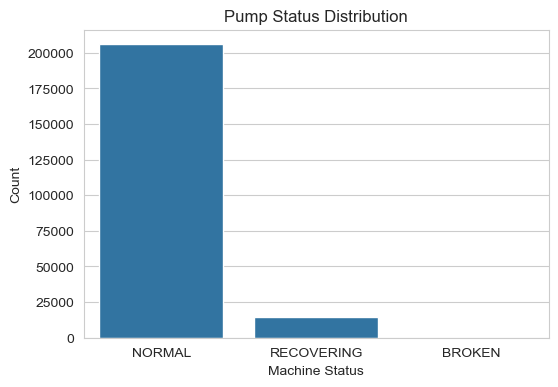

In [9]:
# class distribution (imbalance is very obvious here)
plt.figure(figsize=(6, 4))
sns.countplot(x="machine_status", data=df, order=df["machine_status"].value_counts().index)
plt.title("Pump Status Distribution")
plt.xlabel("Machine Status")
plt.ylabel("Count")
plt.show()

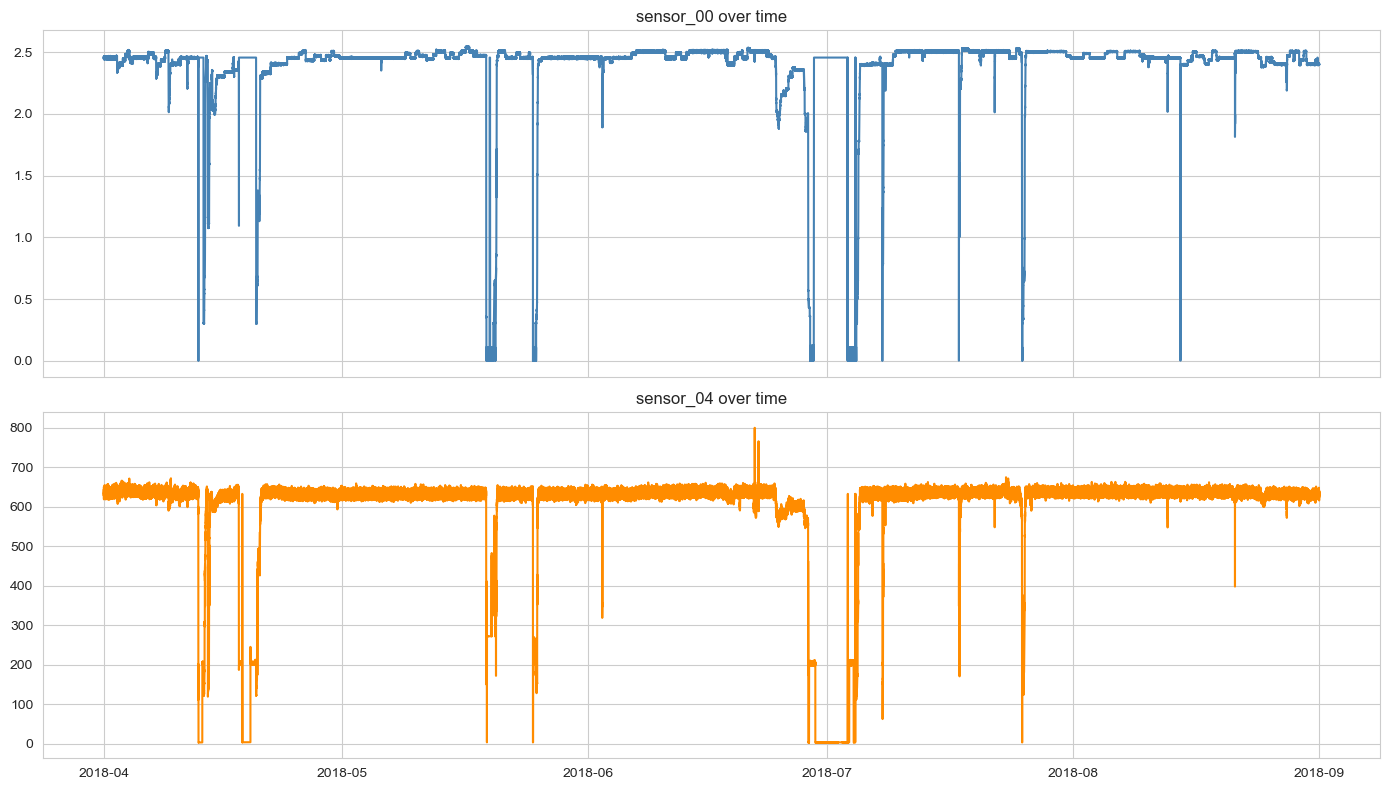

In [10]:
# how a couple of sensors behave over time - useful to actually SEE what happens near a failure
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df["timestamp"], df["sensor_00"], color="steelblue")
axes[0].set_title("sensor_00 over time")

axes[1].plot(df["timestamp"], df["sensor_04"], color="darkorange")
axes[1].set_title("sensor_04 over time")

plt.tight_layout()
plt.show()

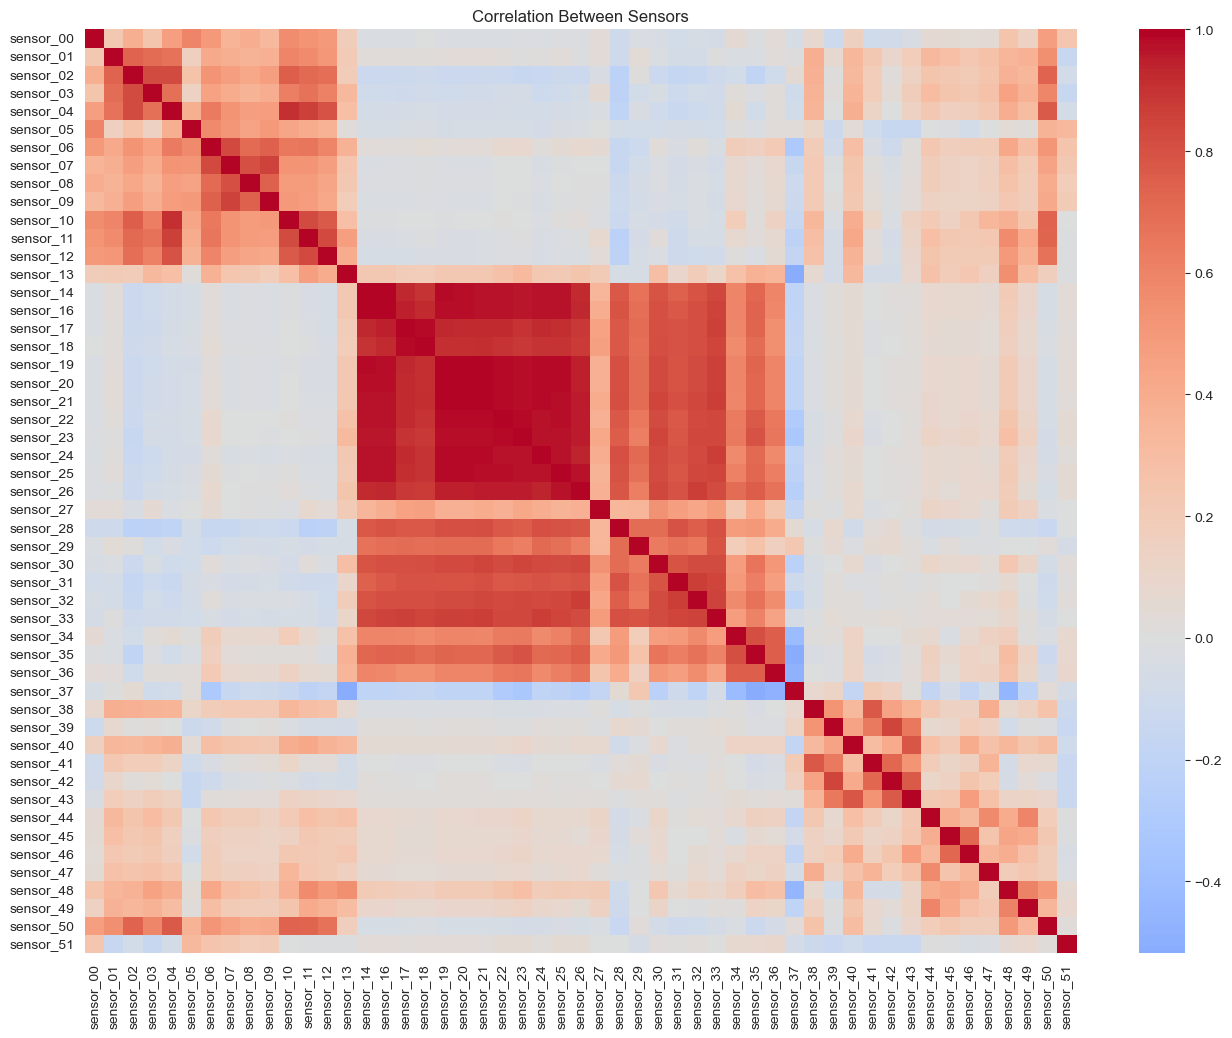

In [11]:
# correlation heatmap between sensors - helps us spot sensors that basically carry the same info
plt.figure(figsize=(16, 12))
corr = df[sensor_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Between Sensors")
plt.show()

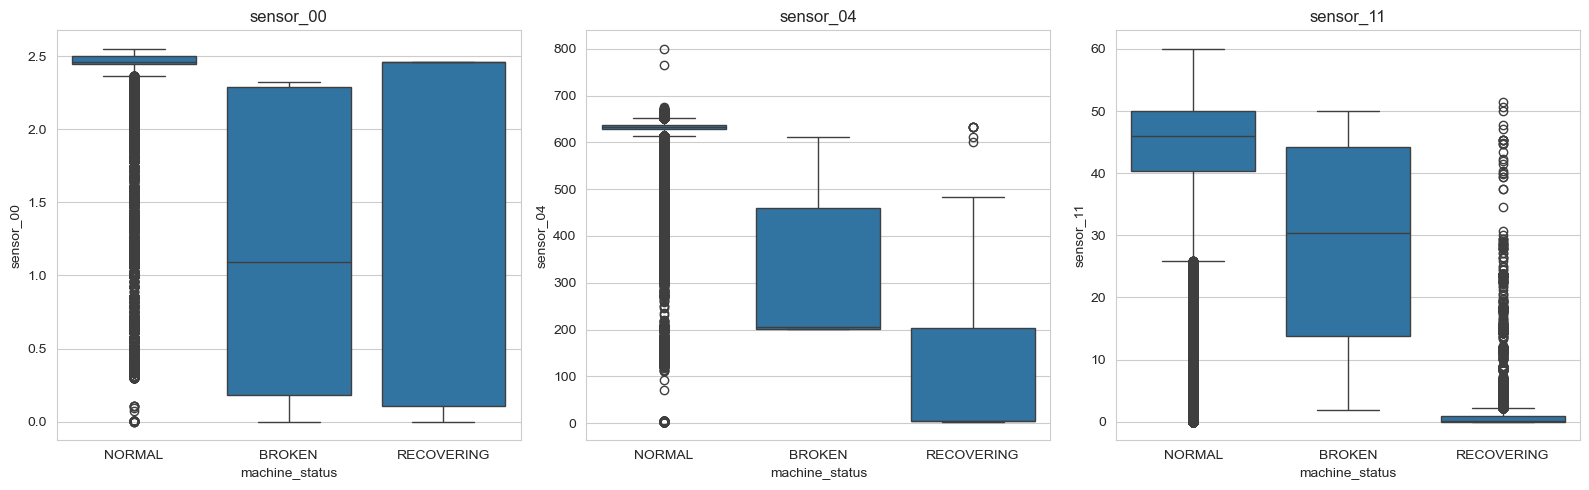

In [12]:
# how a few important-looking sensors differ across the 3 pump statuses
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, ["sensor_00", "sensor_04", "sensor_11"]):
    sns.boxplot(x="machine_status", y=col, data=df, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

# 5) Feature Selection

In [13]:
X = df[sensor_cols]
y = df["status_encoded"]

# step 1 - drop highly correlated sensors
corr_matrix = X.corr().abs()
upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

cols_to_drop = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.95)]
print("Dropping", len(cols_to_drop), "highly correlated sensors:", cols_to_drop)

X = X.drop(columns=cols_to_drop)
print("Sensors remaining:", X.shape[1])

Dropping 11 highly correlated sensors: ['sensor_16', 'sensor_17', 'sensor_18', 'sensor_19', 'sensor_20', 'sensor_21', 'sensor_22', 'sensor_23', 'sensor_24', 'sensor_25', 'sensor_26']
Sensors remaining: 40


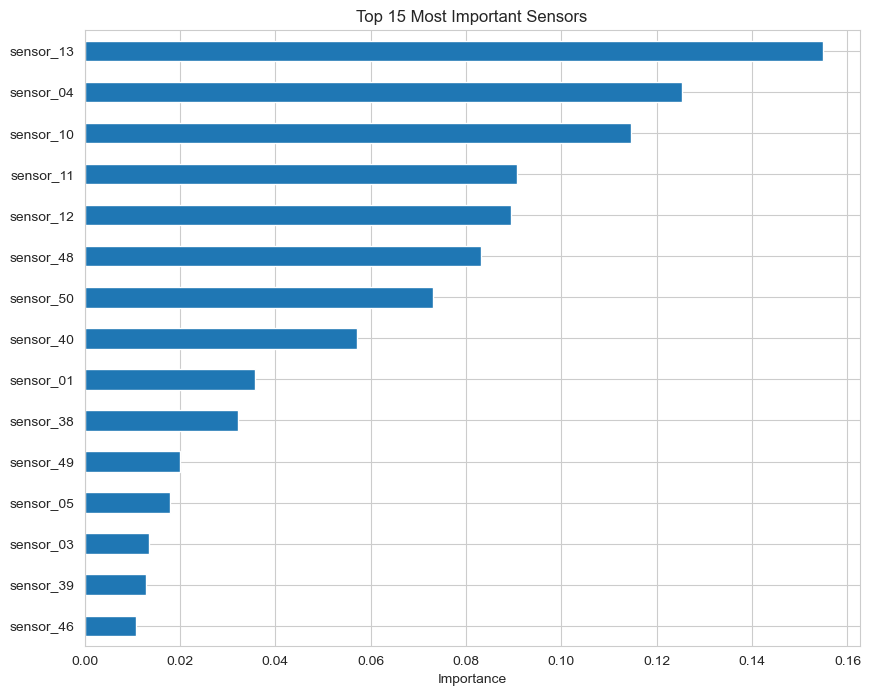

Top features selected: ['sensor_13', 'sensor_04', 'sensor_10', 'sensor_11', 'sensor_12', 'sensor_48', 'sensor_50', 'sensor_40', 'sensor_01', 'sensor_38', 'sensor_49', 'sensor_05', 'sensor_03', 'sensor_39', 'sensor_46']


In [14]:
# step 2 - quick random forest just to rank feature importance
quick_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
quick_rf.fit(X, y)

importance = pd.Series(quick_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importance.head(15).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 15 Most Important Sensors")
plt.xlabel("Importance")
plt.show()

top_features = importance.head(15).index.tolist()
print("Top features selected:", top_features)

In [15]:
X_final = df[top_features]
y_final = df["status_encoded"]

X_final.head()

,sensor_13,sensor_04,sensor_10,sensor_11,sensor_12,sensor_48,sensor_50,sensor_40,sensor_01,sensor_38,sensor_49,sensor_05,sensor_03,sensor_39,sensor_46
0,1.681353,634.3750,37.22740,47.52422,31.11716,157.9861,243.0556,70.57291,47.09201,40.36458,67.70834,76.45975,46.310760,31.51042,50.92593
1,1.681353,634.3750,37.22740,47.52422,31.11716,157.9861,243.0556,70.57291,47.09201,40.36458,67.70834,76.45975,46.310760,31.51042,50.92593
2,1.708474,638.8889,37.86777,48.17723,32.08894,155.9606,241.3194,69.53125,47.35243,41.40625,67.12963,73.54598,46.397570,31.25000,51.21528
3,1.579427,628.1250,38.57977,48.65607,31.67221,155.9606,240.4514,72.13541,47.09201,41.92708,66.84028,76.98898,46.397568,31.51042,51.21528
4,1.683831,636.4583,39.48939,49.06298,31.95202,158.2755,242.1875,76.82291,47.13541,42.70833,66.55093,76.58897,46.397568,31.51042,51.79398


## 6) Train-Test Split Scaling

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (176256, 15)  Test size: (44064, 15)


In [17]:
# scaling helps a bit for some models, and keeps things consistent for the dashboard input later
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 7) Decision Tree Model

In [18]:
dt_model = DecisionTreeClassifier(max_depth=10, class_weight="balanced", random_state=42)
dt_model.fit(X_train_scaled, y_train)

dt_preds = dt_model.predict(X_test_scaled)

dt_accuracy = accuracy_score(y_test, dt_preds)
print("Decision Tree Accuracy:", round(dt_accuracy, 4))
print()
print(classification_report(y_test, dt_preds, target_names=label_encoder.classes_))

Decision Tree Accuracy: 0.9976

              precision    recall  f1-score   support

      BROKEN       0.00      0.00      0.00         2
      NORMAL       1.00      1.00      1.00     41167
  RECOVERING       0.98      1.00      0.99      2895

    accuracy                           1.00     44064
   macro avg       0.66      0.66      0.66     44064
weighted avg       1.00      1.00      1.00     44064



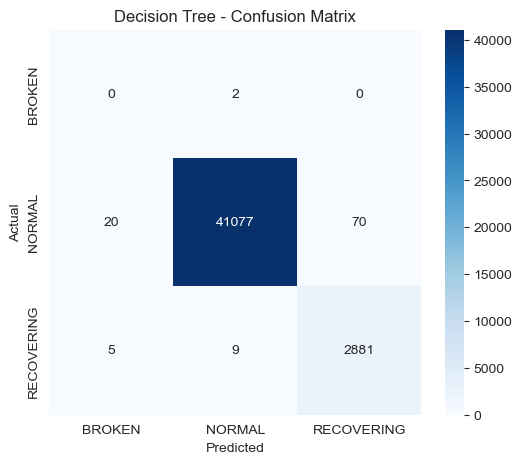

In [19]:
# confusion matrix for the decision tree
cm_dt = confusion_matrix(y_test, dt_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

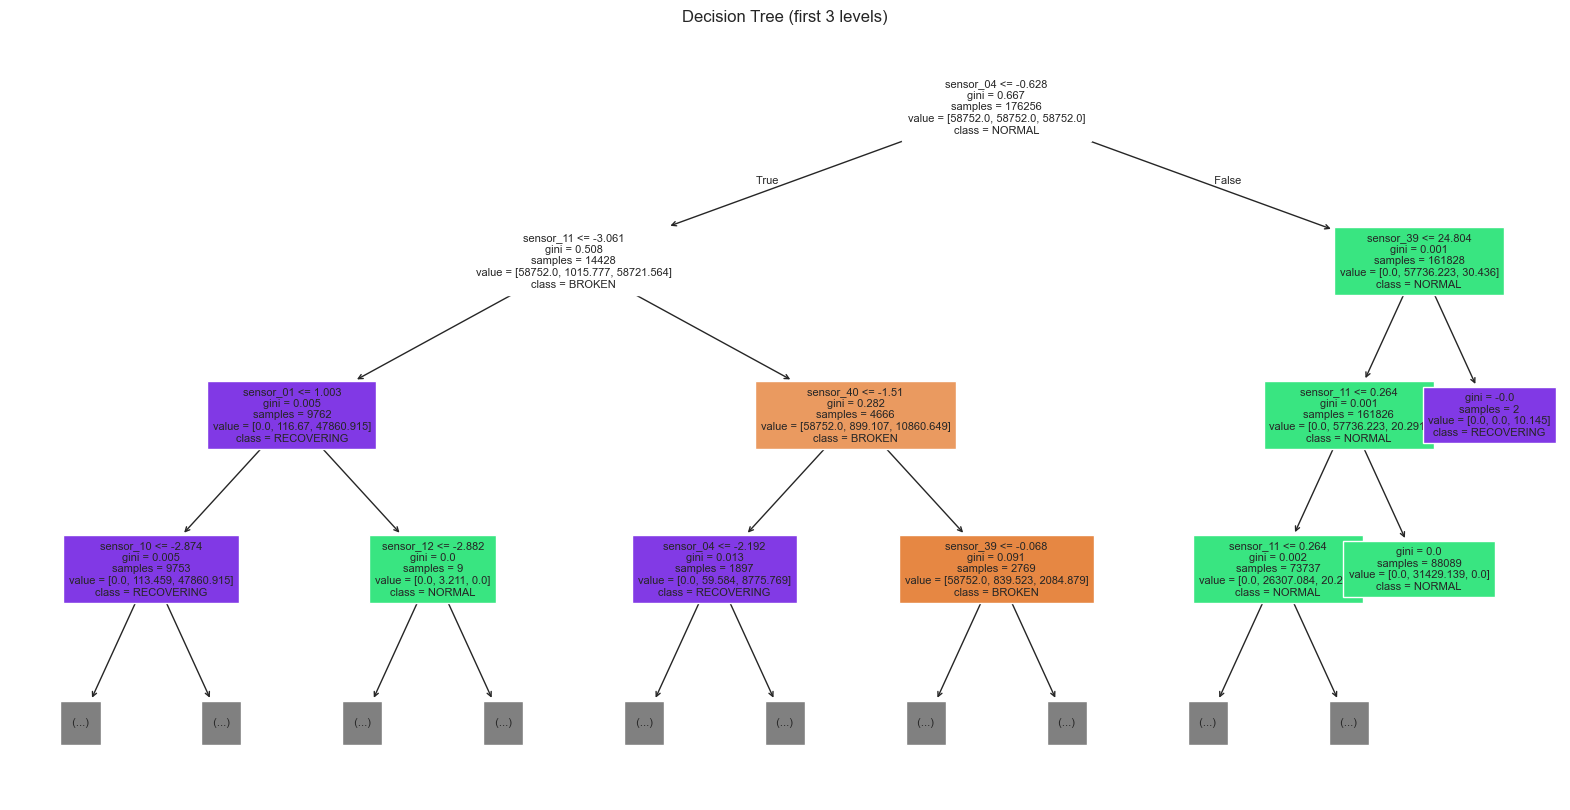

In [20]:
# visualising the tree itself (top few levels only, otherwise it gets unreadable)
plt.figure(figsize=(20, 10))
plot_tree(dt_model, max_depth=3, feature_names=top_features,
          class_names=label_encoder.classes_, filled=True, fontsize=8)
plt.title("Decision Tree (first 3 levels)")
plt.show()

## 8) Random Forest Model

In [22]:
rf_model = RandomForestClassifier(
    n_estimators=200, max_depth=15, class_weight="balanced", random_state=42, n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

rf_preds = rf_model.predict(X_test_scaled)

rf_accuracy = accuracy_score(y_test, rf_preds)
print("Random Forest Accuracy:", round(rf_accuracy, 4))
print()
print(classification_report(y_test, rf_preds, target_names=label_encoder.classes_, zero_division=0))

Random Forest Accuracy: 0.9998

              precision    recall  f1-score   support

      BROKEN       0.00      0.00      0.00         2
      NORMAL       1.00      1.00      1.00     41167
  RECOVERING       1.00      1.00      1.00      2895

    accuracy                           1.00     44064
   macro avg       0.67      0.67      0.67     44064
weighted avg       1.00      1.00      1.00     44064



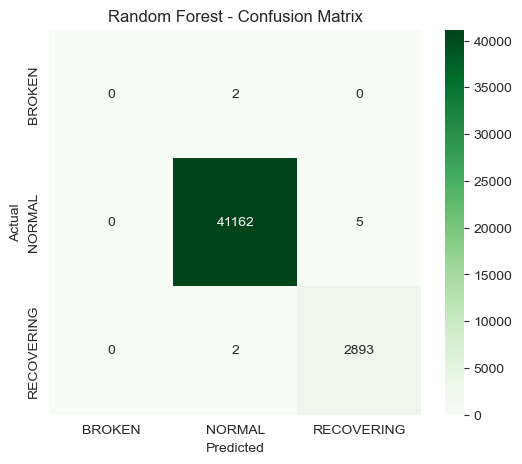

In [23]:
cm_rf = confusion_matrix(y_test, rf_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 9) Model Comparison

In [24]:
results = pd.DataFrame({
    "Model": ["Decision Tree", "Random Forest"],
    "Accuracy": [dt_accuracy, rf_accuracy]
})

results

,Model,Accuracy
0,Decision Tree,0.997594
1,Random Forest,0.999796


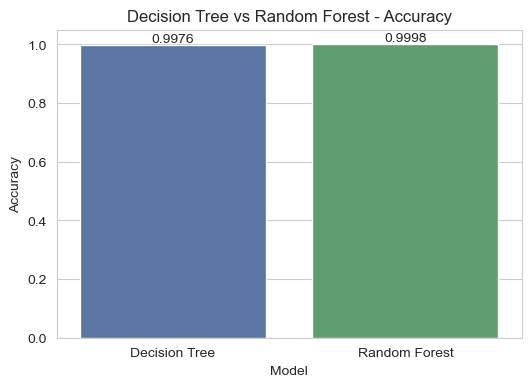

In [25]:
plt.figure(figsize=(6, 4))
sns.barplot(x="Model", y="Accuracy", hue="Model", data=results,
            palette=["#4C72B0", "#55A868"], legend=False)
plt.ylim(0, 1.05)
plt.title("Decision Tree vs Random Forest - Accuracy")

for i, acc in enumerate(results["Accuracy"]):
    plt.text(i, acc + 0.01, f"{acc:.4f}", ha="center")

plt.show()

## 10) Prediction

In [26]:
sample_index = 25   # change this number to test a different row

sample_data = X_test.iloc[[sample_index]]
actual_status = label_encoder.inverse_transform([y_test.iloc[sample_index]])[0]

sample_scaled = scaler.transform(sample_data)
predicted_status = label_encoder.inverse_transform(rf_model.predict(sample_scaled))[0]

print("Actual pump status   :", actual_status)
print("Predicted pump status:", predicted_status)

sample_data

Actual pump status   : NORMAL
Predicted pump status: NORMAL


,sensor_13,sensor_04,sensor_10,sensor_11,sensor_12,sensor_48,sensor_50,sensor_40,sensor_01,sensor_38,sensor_49,sensor_05,sensor_03,sensor_39,sensor_46
212650,13.18761,632.8704,41.0538,45.08546,33.28678,256.3658,193.8657,64.0625,52.517361,50.78125,67.99769,76.87266,46.657986,33.85416,48.32176


In [27]:
# a small helper function so we can predict on any new sensor reading later (used in the dashboard too)
def predict_pump_status(sensor_values):
    """
    sensor_values: dict with keys matching `top_features`
    returns: predicted machine status as text
    """
    input_df = pd.DataFrame([sensor_values])[top_features]
    input_scaled = scaler.transform(input_df)
    prediction = rf_model.predict(input_scaled)
    return label_encoder.inverse_transform(prediction)[0]

# quick test using the average sensor value for each feature (just to check the function works)
avg_values = X_final.mean().to_dict()
predict_pump_status(avg_values)

'NORMAL'

## 11) Saving the model

In [28]:
joblib.dump(rf_model, "pump_rf_model.pkl")
joblib.dump(scaler, "pump_scaler.pkl")
joblib.dump(label_encoder, "pump_label_encoder.pkl")
joblib.dump(top_features, "pump_top_features.pkl")

print("Model and related files saved successfully.")

Model and related files saved successfully.


## 12) Steramlit Dashboard

In [29]:
%%writefile pump_dashboard.py
import streamlit as st
import pandas as pd
import joblib

# load everything we saved from the notebook
model = joblib.load("pump_rf_model.pkl")
scaler = joblib.load("pump_scaler.pkl")
label_encoder = joblib.load("pump_label_encoder.pkl")
top_features = joblib.load("pump_top_features.pkl")

st.set_page_config(page_title="Pump Failure Detection", page_icon=":gear:")

st.title("Industrial Pump Failure Detection")
st.write("Adjust the sensor readings on the left and check the predicted pump health status.")

st.sidebar.header("Sensor Readings")

# build one slider per top sensor - min/max/default just based on typical ranges
sensor_inputs = {}
for feature in top_features:
    sensor_inputs[feature] = st.sidebar.slider(
        feature, min_value=0.0, max_value=1000.0, value=200.0
    )

if st.button("Predict Pump Status"):
    input_df = pd.DataFrame([sensor_inputs])[top_features]
    input_scaled = scaler.transform(input_df)
    prediction = model.predict(input_scaled)
    predicted_status = label_encoder.inverse_transform(prediction)[0]

    if predicted_status == "NORMAL":
        st.success(f"Pump Status: {predicted_status}")
    elif predicted_status == "RECOVERING":
        st.warning(f"Pump Status: {predicted_status}")
    else:
        st.error(f"Pump Status: {predicted_status}")

st.write("---")
st.caption("Model: Random Forest | Project: Industrial Pump Failure Detection Using ML")

Overwriting pump_dashboard.py


SyntaxError: invalid syntax (3295599246.py, line 1)